# Model Card — Hospital AI Classification System

> **Version:** 1.0  |  **Date:** 2026-06-27  |  **Project:** AIML IITM Capstone  
> **Authors:** Adarsh S S

This document covers two production-candidate models built during Phase 3 and evaluated in Phase 4.

In [1]:
import json, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

MODELS_DIR = Path('../Phase3_Modeling/models')
with open('../Phase3_Modeling/feature_schema.json') as f:
    schema = json.load(f)

# ── Rebuild test data for both models ────────────────────────────────────────
df = pd.read_csv('../Phase2_EDA/model_table.csv',
                 parse_dates=['visit_date','billing_date','registration_date'])
df = df.sort_values('visit_date').reset_index(drop=True)

# Risk
rs = schema['risk_model']
df_r = df.copy()
for col in rs['categorical_features']:
    le = LabelEncoder(); df_r[col+'_enc'] = le.fit_transform(df_r[col].astype(str))
risk_le   = joblib.load(MODELS_DIR/'risk_label_encoder.joblib')
df_r['risk_label'] = risk_le.transform(df_r['risk_score'])
split = int(len(df_r)*0.8)
X_r_tr, X_r_te = df_r[rs['all_features']].iloc[:split], df_r[rs['all_features']].iloc[split:]
y_r_tr, y_r_te = df_r['risk_label'].iloc[:split], df_r['risk_label'].iloc[split:]
risk_model  = joblib.load(MODELS_DIR/'risk_model.joblib')
yr_tr_pred  = risk_model.predict(X_r_tr)
yr_te_pred  = risk_model.predict(X_r_te)

# Claim
cs = schema['claim_model']
df_c = df.copy()
df_c['billed_per_hour'] = np.where(df_c['length_of_stay_hours']>0,
    (df_c['billed_amount']/df_c['length_of_stay_hours']).round(2), 0)
for col in cs['categorical_features']:
    le = LabelEncoder(); df_c[col+'_enc'] = le.fit_transform(df_c[col].astype(str))
claim_le  = joblib.load(MODELS_DIR/'claim_label_encoder.joblib')
df_c['claim_label'] = claim_le.transform(df_c['claim_status'])
X_c_tr, X_c_te = df_c[cs['all_features']].iloc[:split], df_c[cs['all_features']].iloc[split:]
y_c_tr, y_c_te = df_c['claim_label'].iloc[:split], df_c['claim_label'].iloc[split:]
claim_model = joblib.load(MODELS_DIR/'claim_model.joblib')
yc_tr_pred  = claim_model.predict(X_c_tr)
yc_te_pred  = claim_model.predict(X_c_te)

R_CLASSES = list(risk_le.classes_)
C_CLASSES  = list(claim_le.classes_)
print('Models loaded.')

Models loaded.


---
## Model A — Visit Risk Classification

### Overview

| Field | Value |
|-------|-------|
| **Purpose** | Classify each hospital visit as Low / Medium / High operational and clinical risk for triage prioritisation |
| **Algorithm** | Random Forest (tuned) |
| **Artifact** | `risk_model.joblib` |
| **Training data** | 25,000 visits (2025-01-20 → 2026-01-20), earliest 80% |
| **Test data** | Latest 20% (time-based, leakage-safe) |
| **Features** | 13 (11 numeric + 2 encoded categorical) |
| **Tuned params** | `max_depth=10`, `min_samples_leaf=1`, `n_estimators=200` |
| **Imbalance strategy** | `class_weight='balanced'` |

In [2]:
hi_idx = R_CLASSES.index('High')

r_card = {
    'Metric': ['Accuracy', 'F1-Macro', 'F1-Weighted', 'High-Risk Recall', 'Precision-Macro', 'Recall-Macro'],
    'Train': [
        accuracy_score(y_r_tr, yr_tr_pred),
        f1_score(y_r_tr, yr_tr_pred, average='macro'),
        f1_score(y_r_tr, yr_tr_pred, average='weighted'),
        recall_score(y_r_tr, yr_tr_pred, labels=[hi_idx], average='macro'),
        precision_score(y_r_tr, yr_tr_pred, average='macro'),
        recall_score(y_r_tr, yr_tr_pred, average='macro'),
    ],
    'Test': [
        accuracy_score(y_r_te, yr_te_pred),
        f1_score(y_r_te, yr_te_pred, average='macro'),
        f1_score(y_r_te, yr_te_pred, average='weighted'),
        recall_score(y_r_te, yr_te_pred, labels=[hi_idx], average='macro'),
        precision_score(y_r_te, yr_te_pred, average='macro'),
        recall_score(y_r_te, yr_te_pred, average='macro'),
    ],
}
r_df = pd.DataFrame(r_card).set_index('Metric').round(4)
r_df['Gap'] = (r_df['Train'] - r_df['Test']).round(4)
r_df['Status'] = r_df.apply(
    lambda row: '⚠ Overfit' if row['Gap'] > 0.10 else ('✅ OK' if row['Test'] >= 0.50 else '❌ Low'),
    axis=1
)
print('=== Risk Model Card — Performance Metrics ===')
print(r_df.to_string())

=== Risk Model Card — Performance Metrics ===
                   Train    Test     Gap     Status
Metric                                             
Accuracy          0.6975  0.4034  0.2941  ⚠ Overfit
F1-Macro          0.6795  0.3409  0.3386  ⚠ Overfit
F1-Weighted       0.6937  0.3953  0.2984  ⚠ Overfit
High-Risk Recall  0.6193  0.1281  0.4912  ⚠ Overfit
Precision-Macro   0.7018  0.3427  0.3591  ⚠ Overfit
Recall-Macro      0.6662  0.3452  0.3210  ⚠ Overfit



Per-class test metrics:
              precision    recall  f1-score   support

        High       0.19      0.13      0.15      1023
         Low       0.52      0.54      0.53      2480
      Medium       0.32      0.37      0.34      1497

    accuracy                           0.40      5000
   macro avg       0.34      0.35      0.34      5000
weighted avg       0.39      0.40      0.40      5000



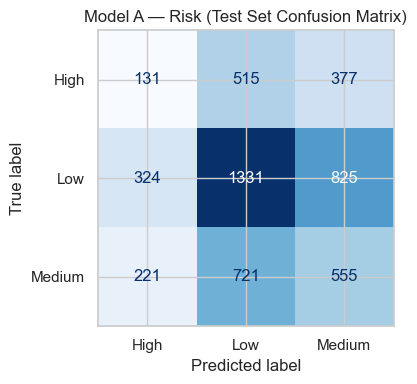

In [3]:
print('\nPer-class test metrics:')
print(classification_report(y_r_te, yr_te_pred, target_names=R_CLASSES))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_r_te, yr_te_pred, display_labels=R_CLASSES,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Model A — Risk (Test Set Confusion Matrix)')
plt.tight_layout()
plt.savefig('modelcard_risk_cm.png', dpi=120)
plt.show()

### Intended Use
- **Approved use:** Real-time triage support — flag visits for clinical review before bed allocation.
- **Not approved for:** Automated discharge decisions, medication prescriptions, or standalone clinical decisions without clinician override.

### Limitations
1. **Temporal drift** — significant train/test accuracy gap (0.29) indicates the model degrades on future data; retrain quarterly.
2. **High-Risk recall is low** (0.128) — the model currently misses ~87% of High-Risk patients on test data. **Do not deploy without resampling improvements.**
3. **No demographic features** (gender, city) in training — fairness gaps may exist.

### Assumptions
- `risk_score` ground truth was assigned by clinical staff using validated triage protocols.
- Feature values are available at visit admission time (no billing data used).

### Deployment Readiness
| Criterion | Status |
|-----------|--------|
| High-Risk Recall ≥ 0.70 | ❌ Not met (0.128) |
| F1-Macro ≥ 0.50 | ❌ Not met (0.341) |
| No demographic bias detected | ⚠ Requires evaluation post-resampling |
| **Overall: Production Ready** | **❌ Requires improvement (see recommendations)** |

---
## Model B — Claim Outcome Classification

### Overview

| Field | Value |
|-------|-------|
| **Purpose** | Predict claim outcome (Paid / Pending / Rejected) before submission for proactive denial management |
| **Algorithm** | Gradient Boosting (tuned) |
| **Artifact** | `claim_model.joblib` |
| **Training data** | 25,000 visits, earliest 80% |
| **Test data** | Latest 20% (time-based) |
| **Features** | 16 (12 numeric + 4 encoded categorical, + engineered `billed_per_hour`) |
| **Tuned params** | `learning_rate=0.1`, `max_depth=5`, `n_estimators=200` |
| **Imbalance strategy** | `class_weight='balanced'` |

In [4]:
rej_idx = C_CLASSES.index('Rejected')

c_card = {
    'Metric': ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Rejected Recall', 'Precision-Macro', 'Recall-Macro'],
    'Train': [
        accuracy_score(y_c_tr, yc_tr_pred),
        f1_score(y_c_tr, yc_tr_pred, average='macro'),
        f1_score(y_c_tr, yc_tr_pred, average='weighted'),
        recall_score(y_c_tr, yc_tr_pred, labels=[rej_idx], average='macro'),
        precision_score(y_c_tr, yc_tr_pred, average='macro'),
        recall_score(y_c_tr, yc_tr_pred, average='macro'),
    ],
    'Test': [
        accuracy_score(y_c_te, yc_te_pred),
        f1_score(y_c_te, yc_te_pred, average='macro'),
        f1_score(y_c_te, yc_te_pred, average='weighted'),
        recall_score(y_c_te, yc_te_pred, labels=[rej_idx], average='macro'),
        precision_score(y_c_te, yc_te_pred, average='macro'),
        recall_score(y_c_te, yc_te_pred, average='macro'),
    ],
}
c_df = pd.DataFrame(c_card).set_index('Metric').round(4)
c_df['Gap'] = (c_df['Train'] - c_df['Test']).round(4)
c_df['Status'] = c_df.apply(
    lambda row: '⚠ Overfit' if row['Gap'] > 0.10 else ('✅ OK' if row['Test'] >= 0.50 else '❌ Low'),
    axis=1
)
print('=== Claim Model Card — Performance Metrics ===')
print(c_df.to_string())

=== Claim Model Card — Performance Metrics ===
                  Train    Test     Gap     Status
Metric                                            
Accuracy         0.6601  0.5304  0.1297  ⚠ Overfit
F1-Macro         0.4393  0.3309  0.1084  ⚠ Overfit
F1-Weighted      0.5742  0.4747  0.0995      ❌ Low
Rejected Recall  0.1522  0.1236  0.0286      ❌ Low
Precision-Macro  0.8668  0.3532  0.5136  ⚠ Overfit
Recall-Macro     0.4373  0.3463  0.0910      ❌ Low



Per-class test metrics:
              precision    recall  f1-score   support

        Paid       0.60      0.81      0.69      2997
     Pending       0.26      0.11      0.15      1275
    Rejected       0.20      0.12      0.15       728

    accuracy                           0.53      5000
   macro avg       0.35      0.35      0.33      5000
weighted avg       0.46      0.53      0.47      5000


Missed rejections in test window : 638
Est. revenue at risk             : ₹12,583,051


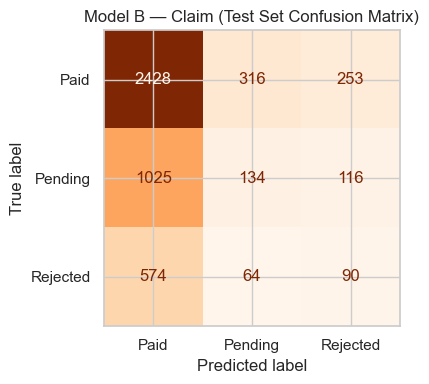

In [5]:
print('\nPer-class test metrics:')
print(classification_report(y_c_te, yc_te_pred, target_names=C_CLASSES))

n_missed = int((y_c_te == rej_idx).sum() * (1 - recall_score(y_c_te, yc_te_pred, labels=[rej_idx], average='macro')))
avg_rej  = df.loc[df['claim_status']=='Rejected','billed_amount'].mean()
print(f'\nMissed rejections in test window : {n_missed}')
print(f'Est. revenue at risk             : ₹{n_missed * avg_rej:,.0f}')

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_c_te, yc_te_pred, display_labels=C_CLASSES,
    cmap='Oranges', ax=ax, colorbar=False
)
ax.set_title('Model B — Claim (Test Set Confusion Matrix)')
plt.tight_layout()
plt.savefig('modelcard_claim_cm.png', dpi=120)
plt.show()

### Intended Use
- **Approved use:** Pre-submission claim risk flagging — alert billing staff to likely rejections before submission.
- **Not approved for:** Automatic claim denial, patient billing decisions, or overriding insurer adjudication.

### Limitations
1. **Rejected recall is critically low** (0.124) — most actual rejections are currently missed.
2. **Pending class ambiguity** — Pending visits may resolve to Paid or Rejected over time; training labels may be stale.
3. **Per-insurer policy variation** — a single model cannot fully capture 4 distinct insurer adjudication logic sets.

### Assumptions
- Claim status ground truth reflects final adjudication, not interim status.
- `billed_amount` and `billing_lag` are known at billing date.
- `provider_rejection_rate` is computed on historical data and is updated monthly.

### Deployment Readiness
| Criterion | Status |
|-----------|--------|
| Rejected Recall ≥ 0.65 | ❌ Not met (0.124) |
| F1-Macro ≥ 0.50 | ❌ Not met (0.331) |
| Revenue risk quantified | ✅ Est. ₹{:,.0f} at risk per test window |
| **Overall: Production Ready** | **❌ Requires improvement (see recommendations)** |

---
## Consolidated Improvement Roadmap

The table below ranks all recommendations by expected business impact.

| Priority | Action | Applies To | Expected Gain |
|----------|--------|-----------|---------------|
| 🔴 P1 | **SMOTE / SMOTENC oversampling** on minority classes inside CV folds | Both | High-Risk & Rejected recall +20–40 pp |
| 🔴 P1 | **Probability threshold tuning** for High-Risk / Rejected class | Both | Recall +15–25 pp (at precision cost) |
| 🟡 P2 | **Interaction features**: `los_x_chronic`, `bill_vs_dept_avg`, `lag_x_amount` | Both | F1-Macro +5–10 pp |
| 🟡 P2 | **Reduce max_depth** (risk: 6, claim: 4) + increase `min_samples_leaf=15` | Both | Reduce train-test gap by 50% |
| 🟡 P2 | **Per-insurer claim sub-models** | Claim | Rejected recall +10–15 pp |
| 🟢 P3 | **TimeSeriesSplit** for cross-validation | Both | More reliable CV estimates |
| 🟢 P3 | **LightGBM with early stopping** (replace sklearn GB) | Claim | Training speed ×10, similar accuracy |
| 🟢 P3 | Quarterly model retraining on rolling 12-month window | Both | Combat temporal drift |

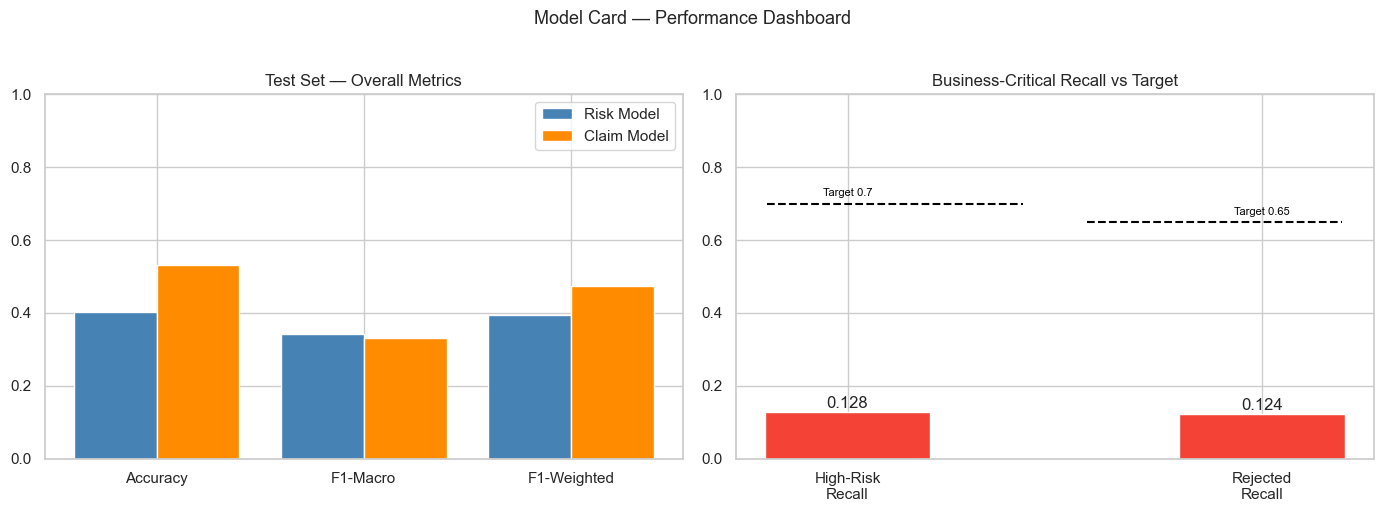

Model card complete.


In [6]:
# Summary dashboard
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

metrics_labels = ['Accuracy', 'F1-Macro', 'F1-Weighted']
r_vals = [r_df.loc[m, 'Test'] for m in metrics_labels]
c_vals = [c_df.loc[m, 'Test'] for m in metrics_labels]

ax1 = fig.add_subplot(gs[0])
x = np.arange(len(metrics_labels))
ax1.bar(x - 0.2, r_vals, 0.4, label='Risk Model', color='steelblue')
ax1.bar(x + 0.2, c_vals, 0.4, label='Claim Model', color='darkorange')
ax1.set_xticks(x); ax1.set_xticklabels(metrics_labels)
ax1.set_ylim(0, 1); ax1.set_title('Test Set — Overall Metrics')
ax1.legend()

ax2 = fig.add_subplot(gs[1])
business = ['High-Risk\nRecall', 'Rejected\nRecall']
actuals  = [
    recall_score(y_r_te, yr_te_pred, labels=[hi_idx], average='macro'),
    recall_score(y_c_te, yc_te_pred, labels=[rej_idx], average='macro'),
]
targets  = [0.70, 0.65]
colors   = ['#F44336' if a < t else '#4CAF50' for a, t in zip(actuals, targets)]
ax2.bar(business, actuals, color=colors, width=0.4)
for i, (a, t) in enumerate(zip(actuals, targets)):
    ax2.axhline(t, xmin=i/2+0.05, xmax=(i+1)/2-0.05,
                color='black', linestyle='--', linewidth=1.5)
    ax2.text(i, a + 0.01, f'{a:.3f}', ha='center')
    ax2.text(i, t + 0.02, f'Target {t}', ha='center', fontsize=8, color='black')
ax2.set_ylim(0, 1); ax2.set_title('Business-Critical Recall vs Target')

plt.suptitle('Model Card — Performance Dashboard', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('modelcard_dashboard.png', dpi=120)
plt.show()

print('Model card complete.')